In [1]:
from pathlib import Path
import json
import math
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

RUNS_DIR = Path('./runs')
RUNS_DIR

PosixPath('runs')

In [2]:
def infer_dataset_type(data, folder_name=''):
    dataset_name = (
        data.get('hyperparameters', {}).get('dataset', '')
        or data.get('dataset', '')
        or folder_name
    ).lower()

    if 'aug' in dataset_name or 'augment' in dataset_name:
        return 'augmenté'
    return 'normal'


def load_run_jsons(runs_dir: Path):
    records = []
    if not runs_dir.exists():
        raise FileNotFoundError(f'Le dossier {runs_dir} n\'existe pas.')

    for subdir in sorted([p for p in runs_dir.iterdir() if p.is_dir()]):
        json_files = sorted(subdir.rglob('*.json'))

        if not json_files:
            print(f'[INFO] Aucun JSON trouvé dans {subdir.name}')
            continue

        for json_path in json_files:
            try:
                with open(json_path, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                records.append({
                    'subdir': subdir.name,
                    'json_path': json_path,
                    'data': data,
                    'dataset_type': infer_dataset_type(data, subdir.name),
                    'model': data.get('model', data.get('hyperparameters', {}).get('model', 'UnknownModel')),
                })
            except Exception as e:
                print(f'[ERREUR] Impossible de lire {json_path}: {e}')

    return records


records = load_run_jsons(RUNS_DIR)
print(f'{len(records)} fichier(s) JSON trouvé(s).')

[INFO] Aucun JSON trouvé dans dinov2_segmentation
8 fichier(s) JSON trouvé(s).


In [3]:
summary_rows = []
for rec in records:
    data = rec['data']
    history = data.get('history', [])
    hp = data.get('hyperparameters', {})
    summary_rows.append({
        'run_folder': rec['subdir'],
        'json_file': rec['json_path'].name,
        'model': rec['model'],
        'dataset': hp.get('dataset', 'N/A'),
        'dataset_type': rec['dataset_type'],
        'epochs_trained': data.get('epochs_trained', len(history)),
        'best_val_f1': data.get('best_val_f1', None),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.sort_values(['run_folder', 'json_file']).reset_index(drop=True)

,run_folder,json_file,model,dataset,dataset_type,epochs_trained,best_val_f1
0,cnn_boxes_v3_augmented,results.json,SimpleCNN3,patches_v3_augmented,augmenté,10,0.857941
1,cnn_boxes_v3_normal,results.json,SimpleCNN3,N/A,normal,10,0.878049
2,dinov2_vits14_augmented,results.json,dinov2_vits14_binary_head,N/A,augmenté,10,0.944350
3,dinov2_vits14_normal,results.json,dinov2_vits14_binary_head,N/A,normal,10,0.958349
4,resnet18_ft_seed42,results.json,resnet18_ft,N/A,normal,19,0.881958
5,resnet18_ft_seed42_aug,results.json,resnet18_ft,N/A,augmenté,20,0.843520
6,vit_v1_seed42,results.json,vit_v1,N/A,normal,7,0.879479
7,vit_v2_seed42_aug,results.json,vit_v2,N/A,augmenté,17,0.934697


In [10]:
DEFAULT_METRICS = [
    'loss',
    'accuracy',
    'balanced_accuracy',
    'precision',
    'recall',
    'f1',
    'auroc',
    'ap',
]


def history_to_dataframe(history):
    rows = []
    for item in history:
        row = {'epoch': item.get('epoch')}

        for split in ['train', 'val']:
            split_data = item.get(split, {})
            for k, v in split_data.items():
                row[f'{split}_{k}'] = v

        if 'time_sec' in item:
            row['time_sec'] = item['time_sec']

        rows.append(row)

    return pd.DataFrame(rows)


def make_run_title(rec):
    data = rec['data']
    hp = data.get('hyperparameters', {})
    model = rec['model']
    dataset = hp.get('dataset', 'dataset inconnu')
    dataset_type = rec['dataset_type']
    return f"{rec['subdir']} | {model} | dataset: {dataset} ({dataset_type})"


def plot_run_metrics(rec, metrics=None, show_time=True):
    if metrics is None:
        metrics = DEFAULT_METRICS

    history = rec['data'].get('history', [])
    if not history:
        print(f"[INFO] Pas d'historique pour {rec['json_path']}")
        return

    df = history_to_dataframe(history)
    title_prefix = make_run_title(rec)

    available_metrics = []
    for metric in metrics:
        if f'train_{metric}' in df.columns or f'val_{metric}' in df.columns:
            available_metrics.append(metric)

    for metric in available_metrics:
        plt.figure()
        if f'train_{metric}' in df.columns:
            plt.plot(df['epoch'], df[f'train_{metric}'], marker='o', label='train')
        if f'val_{metric}' in df.columns:
            plt.plot(df['epoch'], df[f'val_{metric}'], marker='s', label='val')

        plt.title(f'{title_prefix} | métrique: {metric}')
        plt.xlabel('Époque')
        plt.ylabel(metric)
        plt.legend()
        plt.tight_layout()
        plt.show()

    if show_time and 'time_sec' in df.columns:
        plt.figure()
        plt.plot(df['epoch'], df['time_sec'], marker='o')
        plt.title(f'{title_prefix} | temps par époque')
        plt.xlabel('Époque')
        plt.ylabel('Temps (sec)')
        plt.tight_layout()
        plt.show()


def plot_run_metrics2(rec, metrics=None, show_time=True, subplot_cols=4):
    """
    Args:
        rec: run record with 'data' containing 'history'
        metrics: list of metric names (e.g., ['loss', 'dice', 'iou'])
        show_time: if True, add timing subplot
        subplot_cols: number of columns for subplots
    """
    if metrics is None:
        metrics = DEFAULT_METRICS

    history = rec['data'].get('history', [])
    if not history:
        print(f"[INFO] Pas d'historique pour {rec['json_path']}")
        return

    df = history_to_dataframe(history)
    title_prefix = make_run_title(rec)

    # Find available metrics
    available_metrics = []
    for metric in metrics:
        if f'train_{metric}' in df.columns or f'val_{metric}' in df.columns:
            available_metrics.append(metric)
    
    if not available_metrics:
        print(f"[INFO] Aucune métrique disponible pour {title_prefix}")
        return

    # Calculate subplot layout
    n_metrics = len(available_metrics)
    n_cols = subplot_cols
    n_rows = (n_metrics + n_cols - 1) // n_cols  # ceiling division
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_metrics == 1:
        axes = [axes]  # make 1D for single subplot
    elif n_rows == 1:
        axes = axes.reshape(1, -1)  # make 2D for single row
    
    # Plot each metric
    for i, metric in enumerate(available_metrics):
        row = i // n_cols
        col = i % n_cols
        
        ax = axes[row][col]
        
        if f'train_{metric}' in df.columns:
            ax.plot(df['epoch'], df[f'train_{metric}'], marker='o', 
                   label='train', linewidth=2, markersize=4)
        if f'val_{metric}' in df.columns:
            ax.plot(df['epoch'], df[f'val_{metric}'], marker='s', 
                   label='val', linewidth=2, markersize=4)
        
        ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(metric)
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for i in range(n_metrics, n_rows * n_cols):
        row = i // n_cols
        col = i % n_cols
        fig.delaxes(axes[row][col])
    
    fig.suptitle(f'{title_prefix}', fontsize=16, y=0.98)
    plt.tight_layout()
    plt.savefig(f'images/{rec["subdir"]}_metrics.png')
    plt.show()

def plot_all_runs(records, metrics=None, show_time=False):
    for rec in records:
        print('=' * 120)
        print(make_run_title(rec))
        print(f'JSON: {rec["json_path"]}')
        plot_run_metrics(rec, metrics=metrics, show_time=show_time)

def plot_all_runs2(records, metrics=None, show_time=False):
    for rec in records:
        print('=' * 120)
        print(make_run_title(rec))
        print(f'JSON: {rec["json_path"]}')
        plot_run_metrics2(rec, metrics=metrics, show_time=show_time)


In [11]:
# Tracer toutes les runs

cnn_boxes_v3_augmented | SimpleCNN3 | dataset: patches_v3_augmented (augmenté)
JSON: runs/cnn_boxes_v3_augmented/results.json


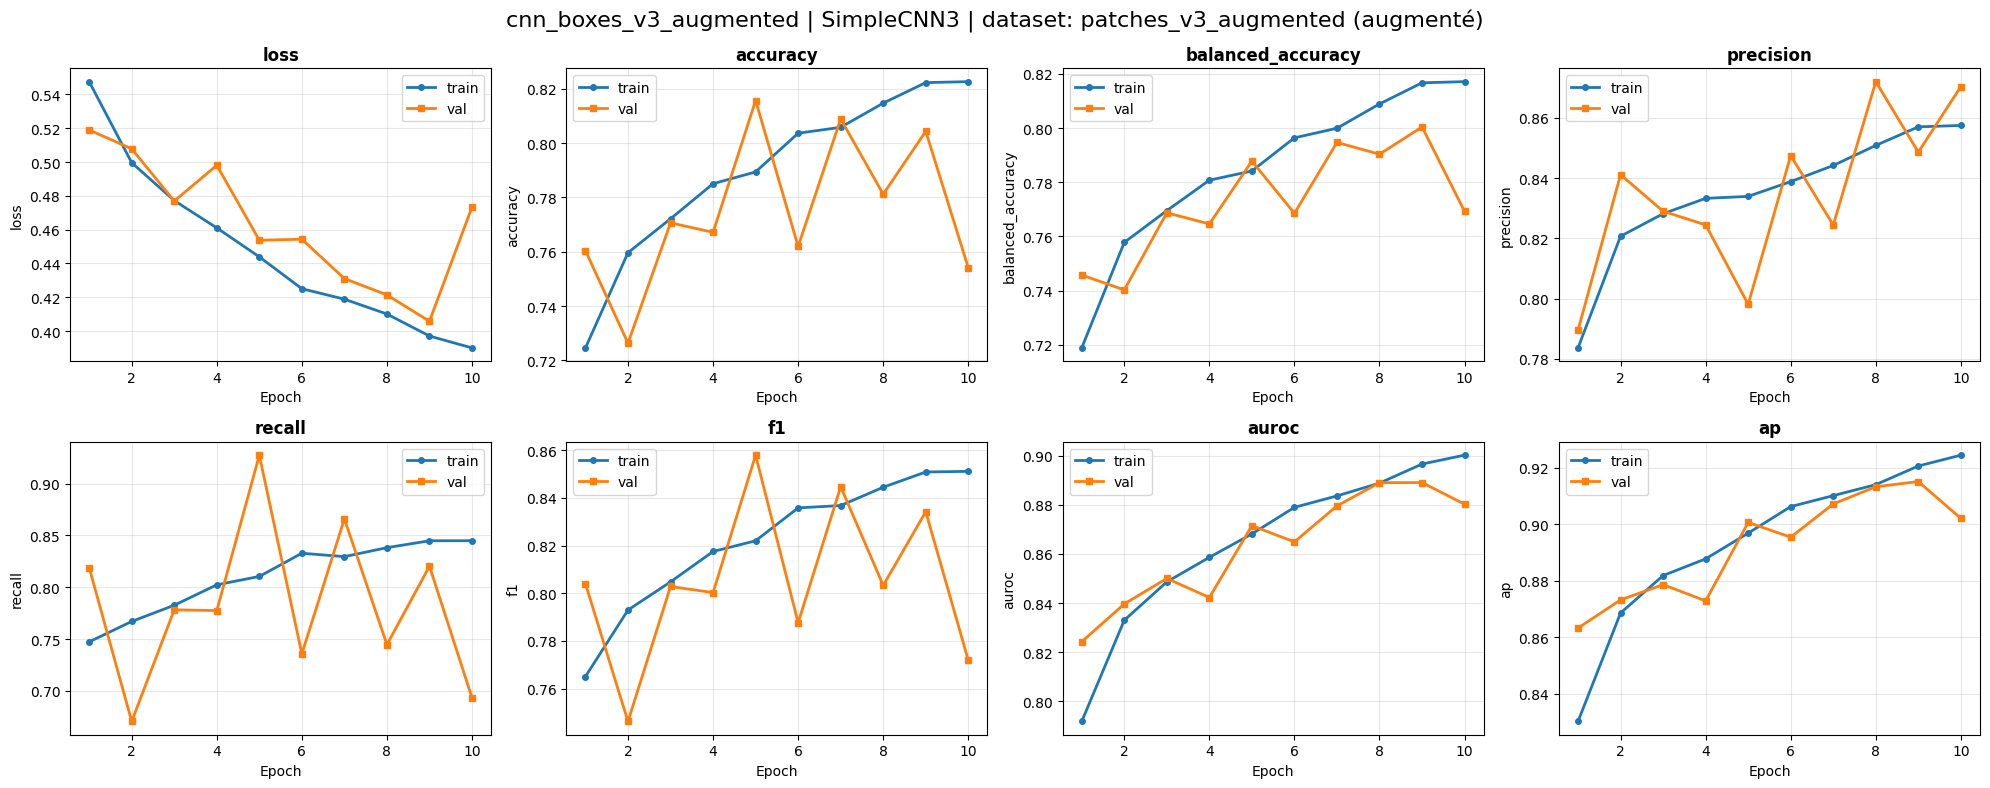

cnn_boxes_v3_normal | SimpleCNN3 | dataset: dataset inconnu (normal)
JSON: runs/cnn_boxes_v3_normal/results.json


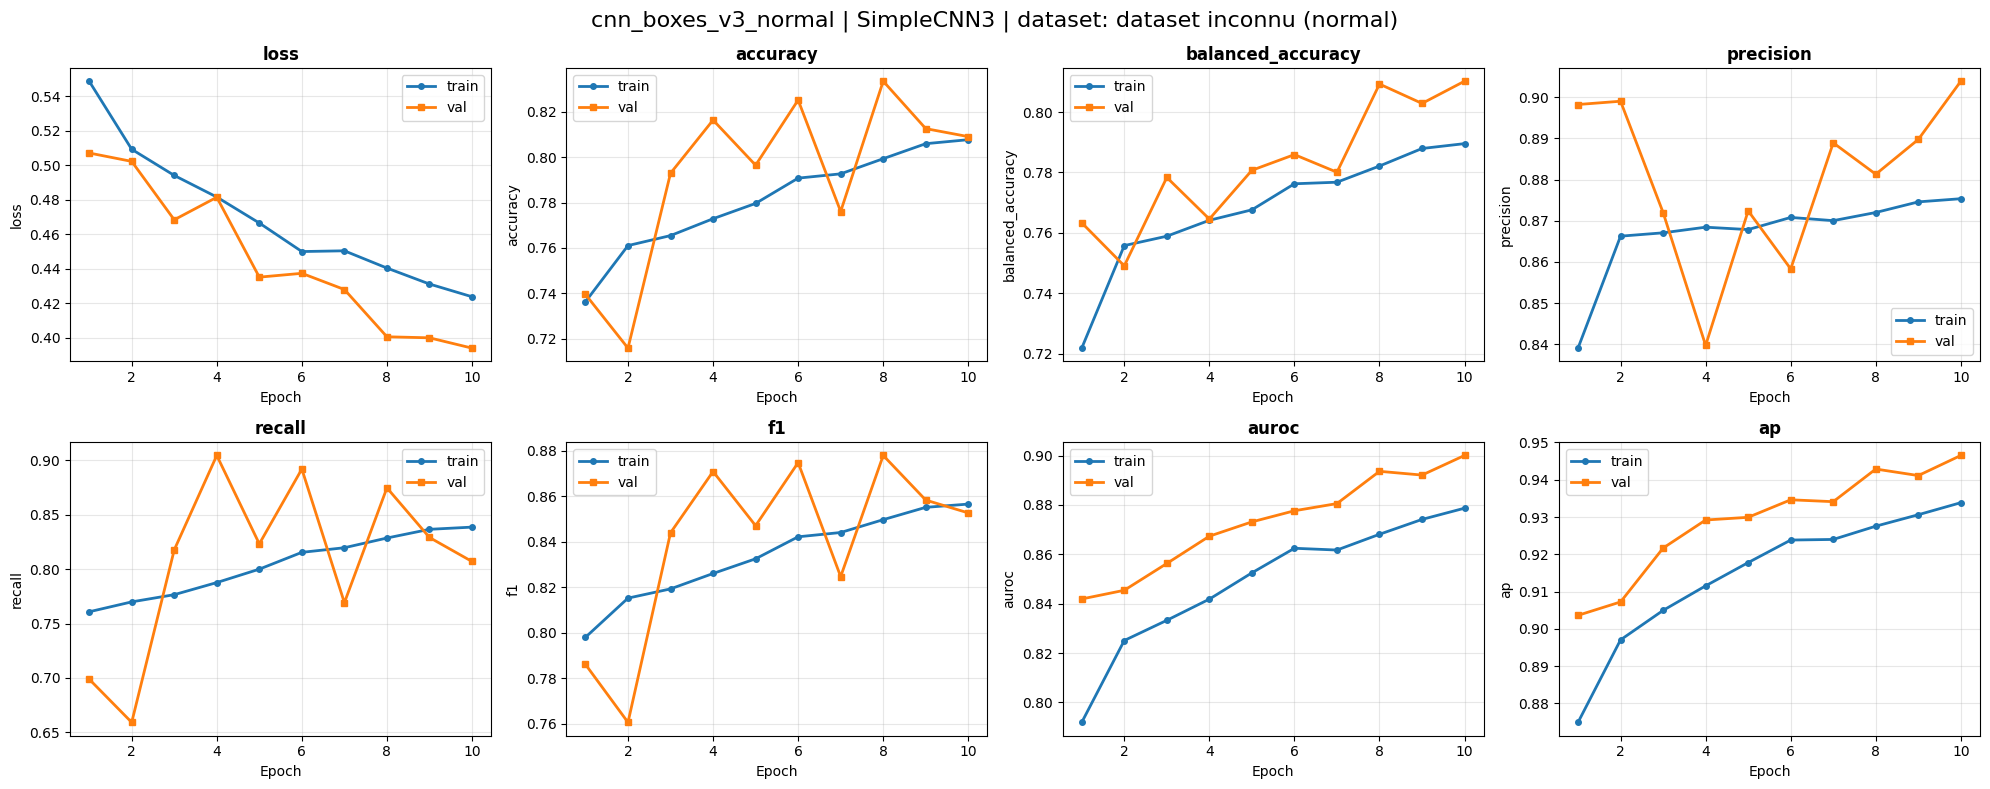

dinov2_vits14_augmented | dinov2_vits14_binary_head | dataset: dataset inconnu (augmenté)
JSON: runs/dinov2_vits14_augmented/results.json


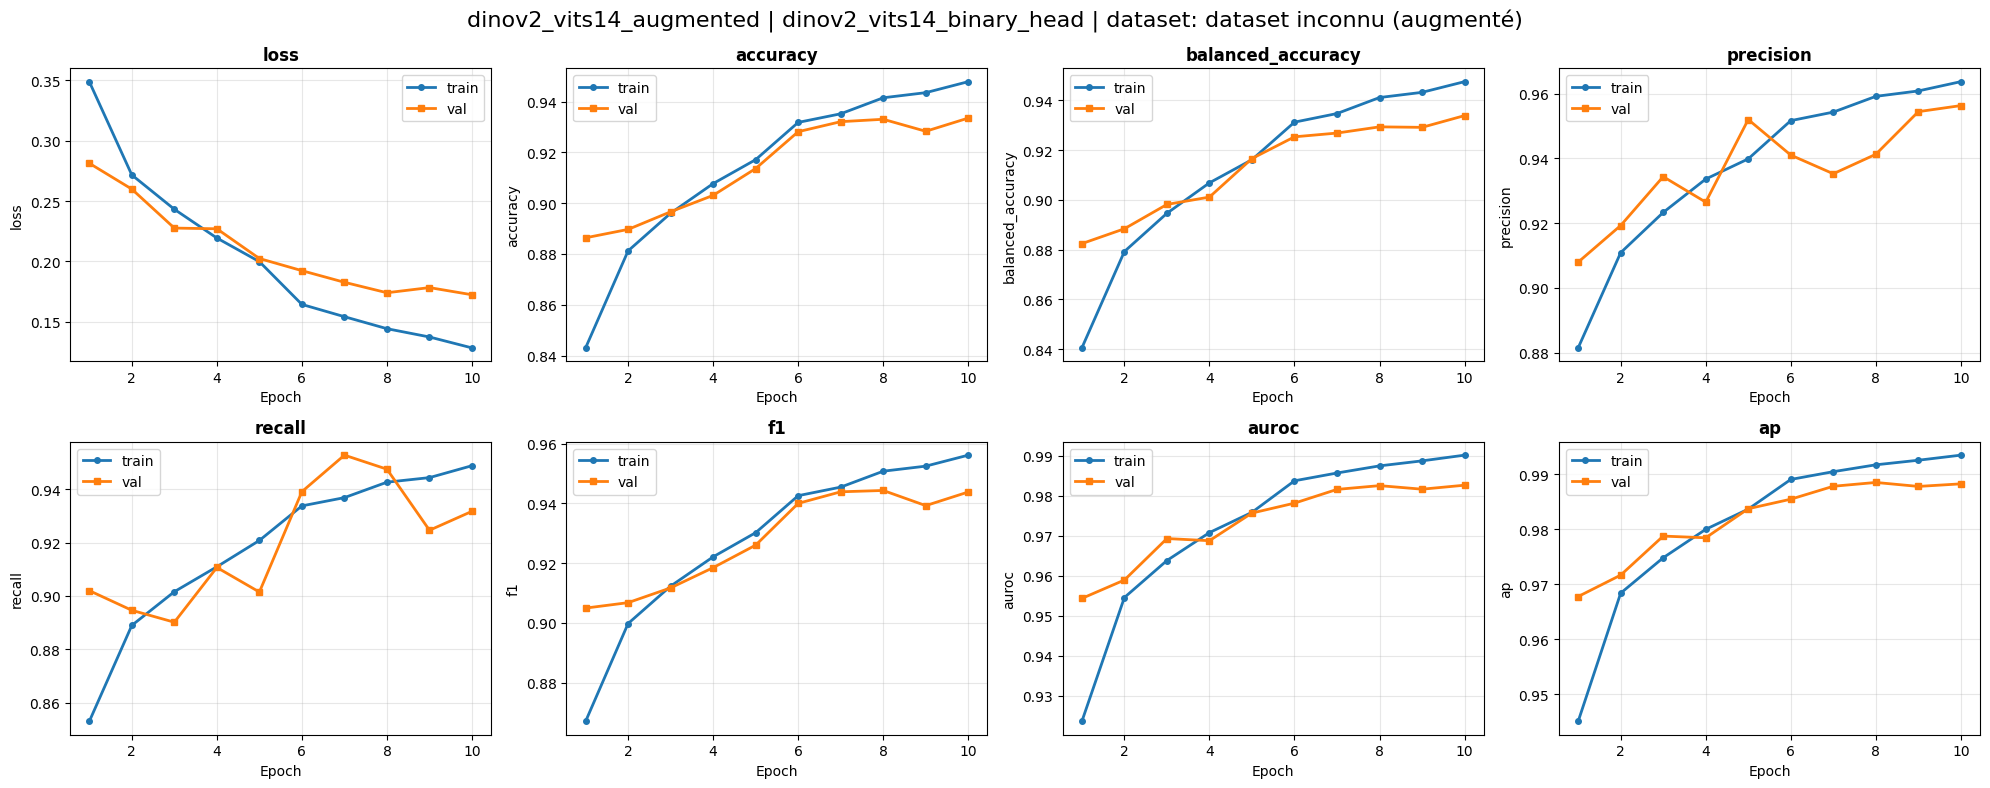

dinov2_vits14_normal | dinov2_vits14_binary_head | dataset: dataset inconnu (normal)
JSON: runs/dinov2_vits14_normal/results.json


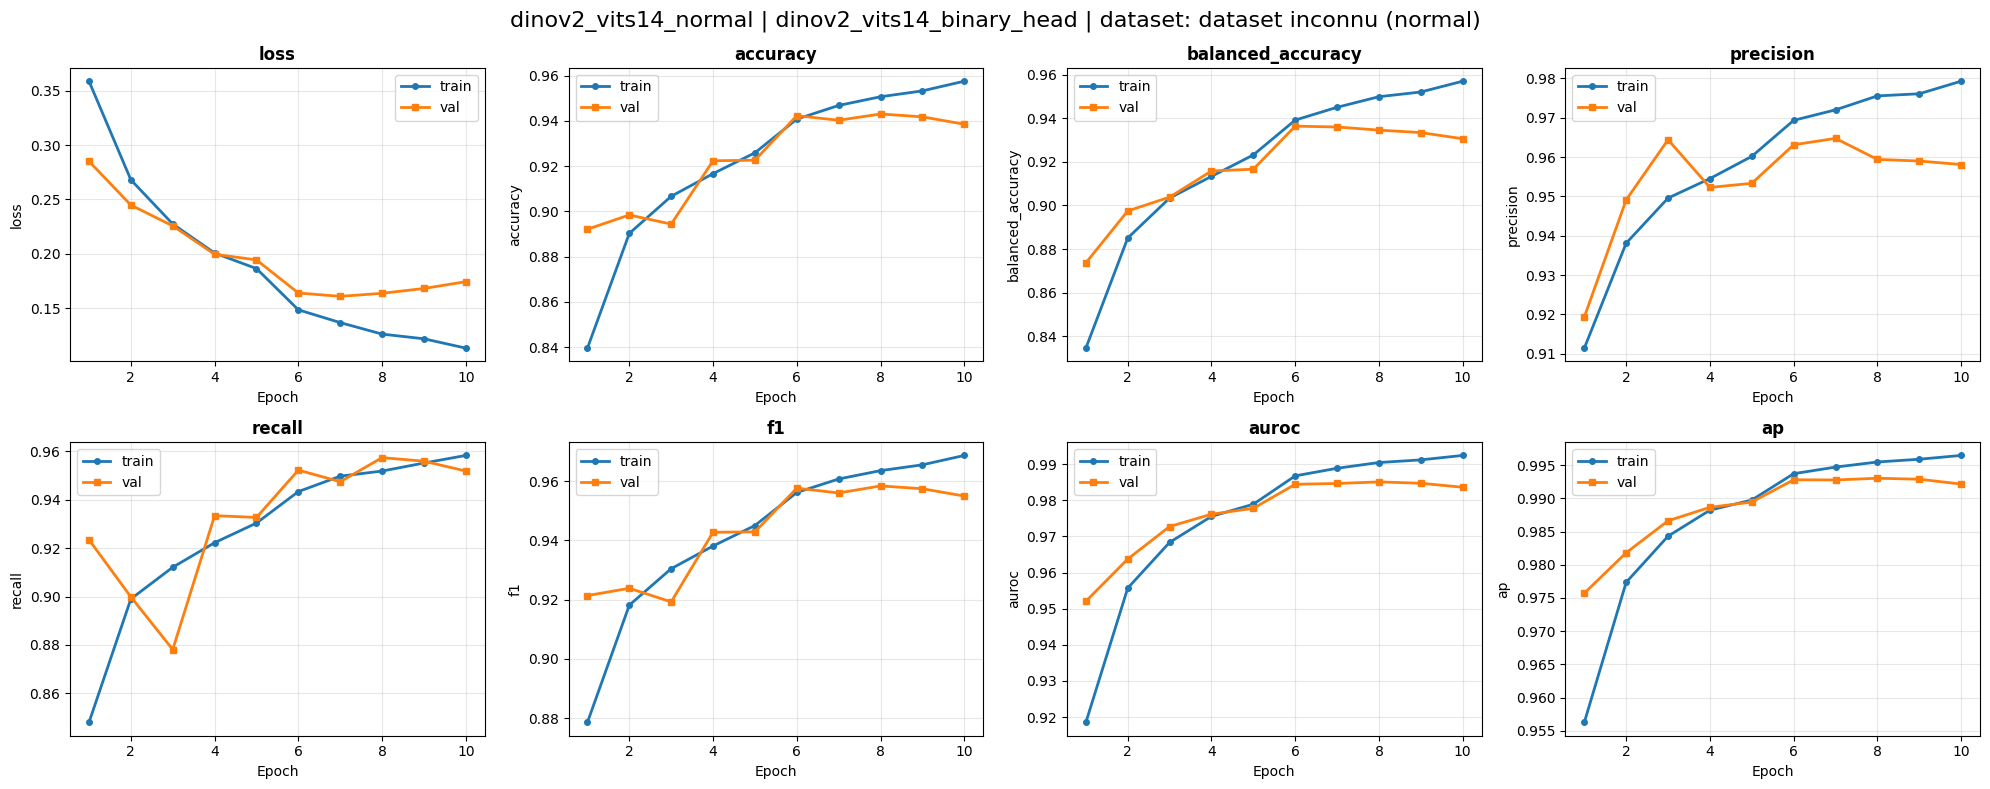

resnet18_ft_seed42 | resnet18_ft | dataset: dataset inconnu (normal)
JSON: runs/resnet18_ft_seed42/results.json


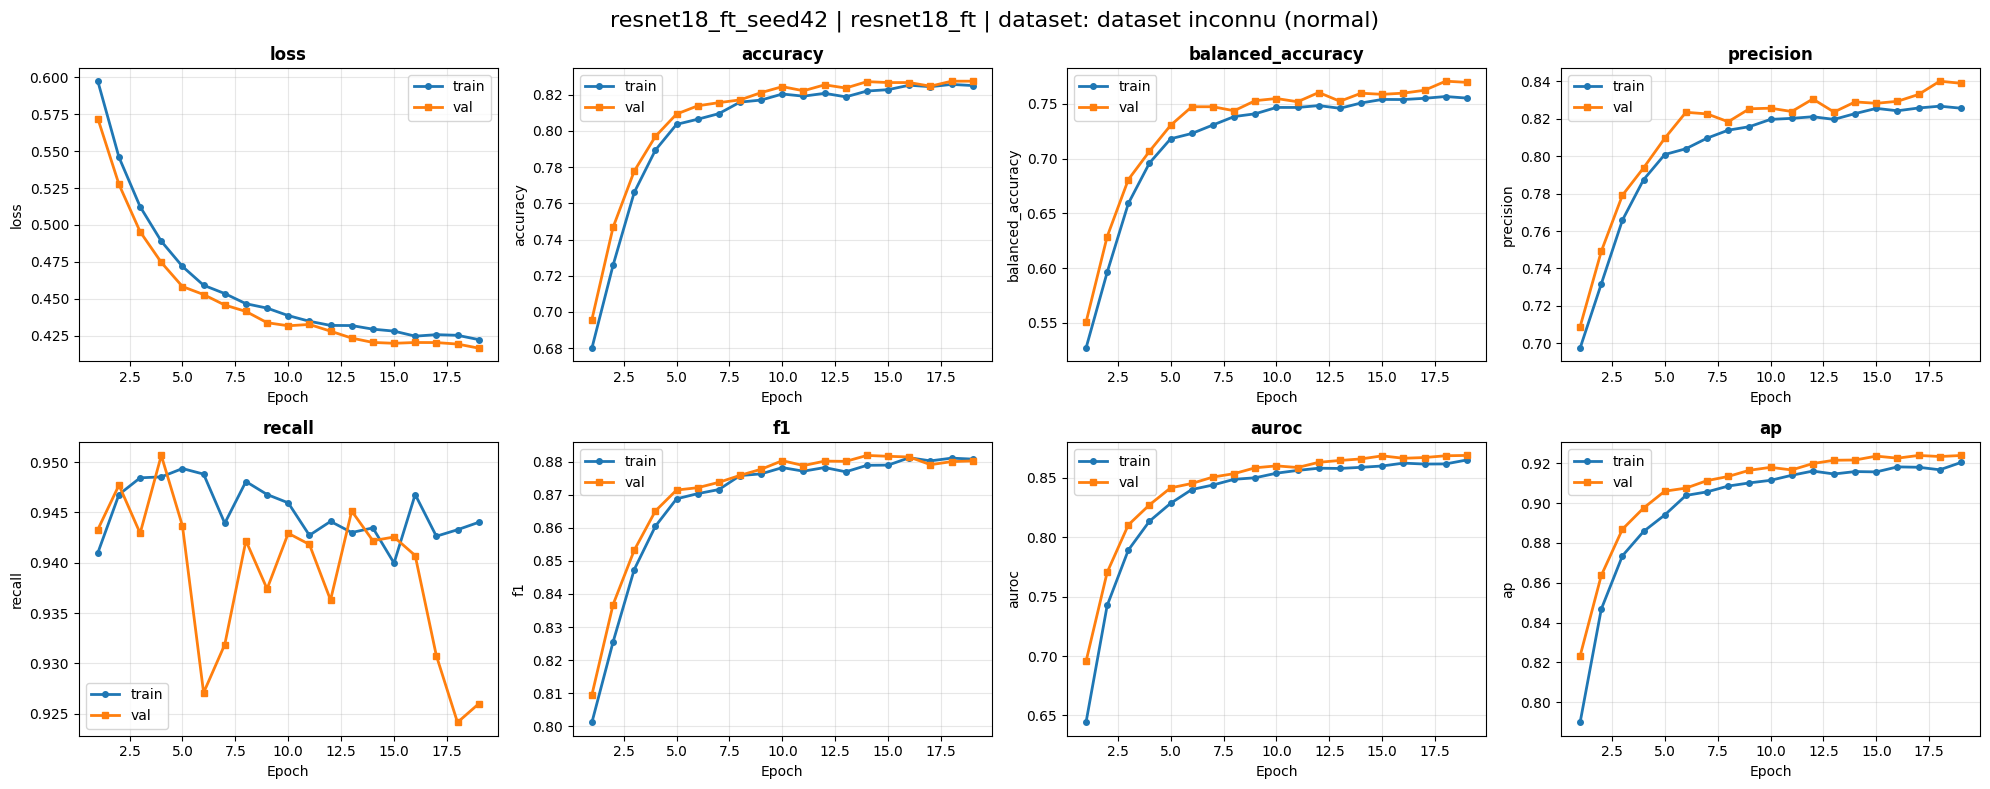

resnet18_ft_seed42_aug | resnet18_ft | dataset: dataset inconnu (augmenté)
JSON: runs/resnet18_ft_seed42_aug/results.json


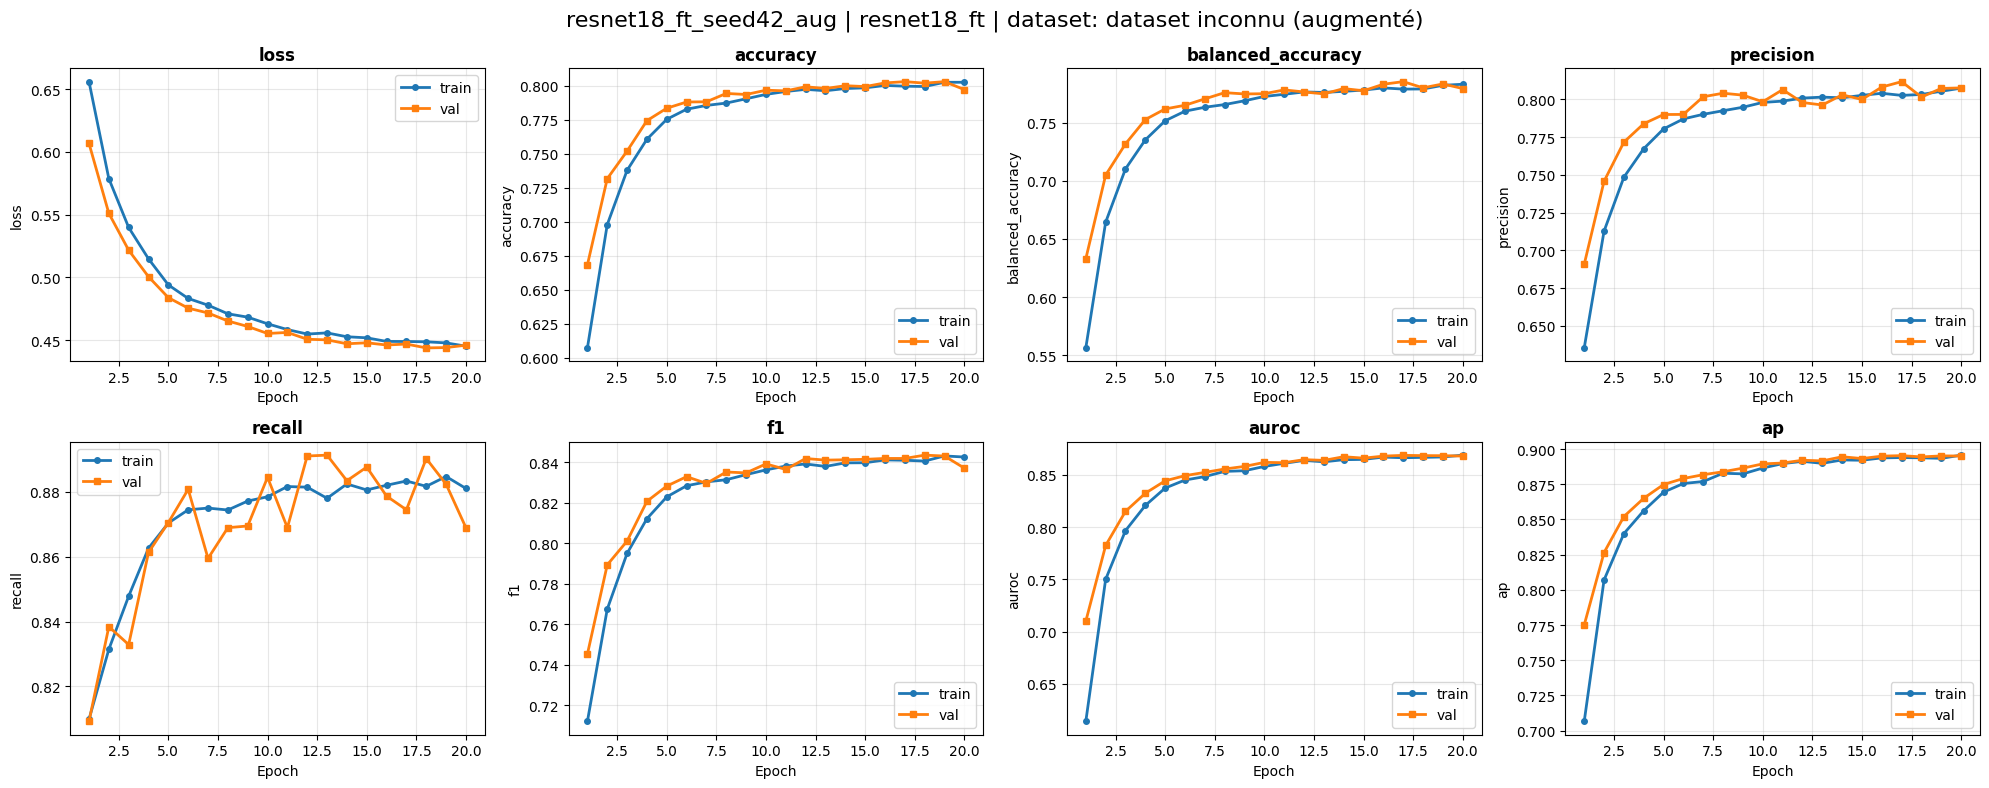

vit_v1_seed42 | vit_v1 | dataset: dataset inconnu (normal)
JSON: runs/vit_v1_seed42/results.json


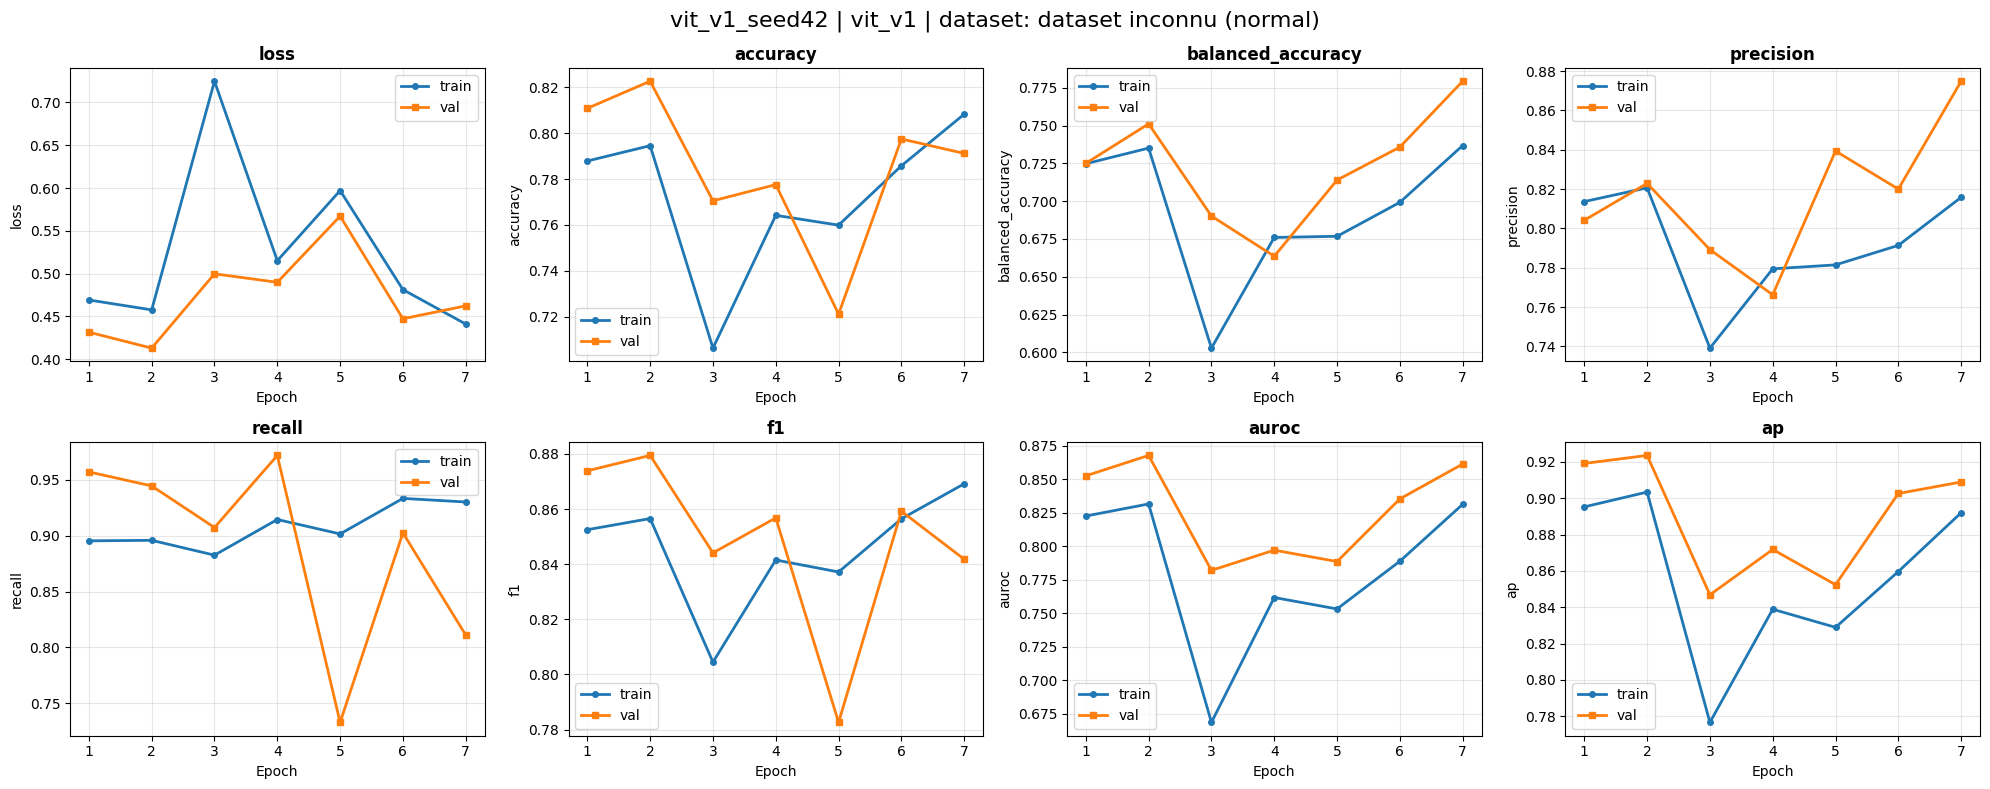

vit_v2_seed42_aug | vit_v2 | dataset: dataset inconnu (augmenté)
JSON: runs/vit_v2_seed42_aug/results.json


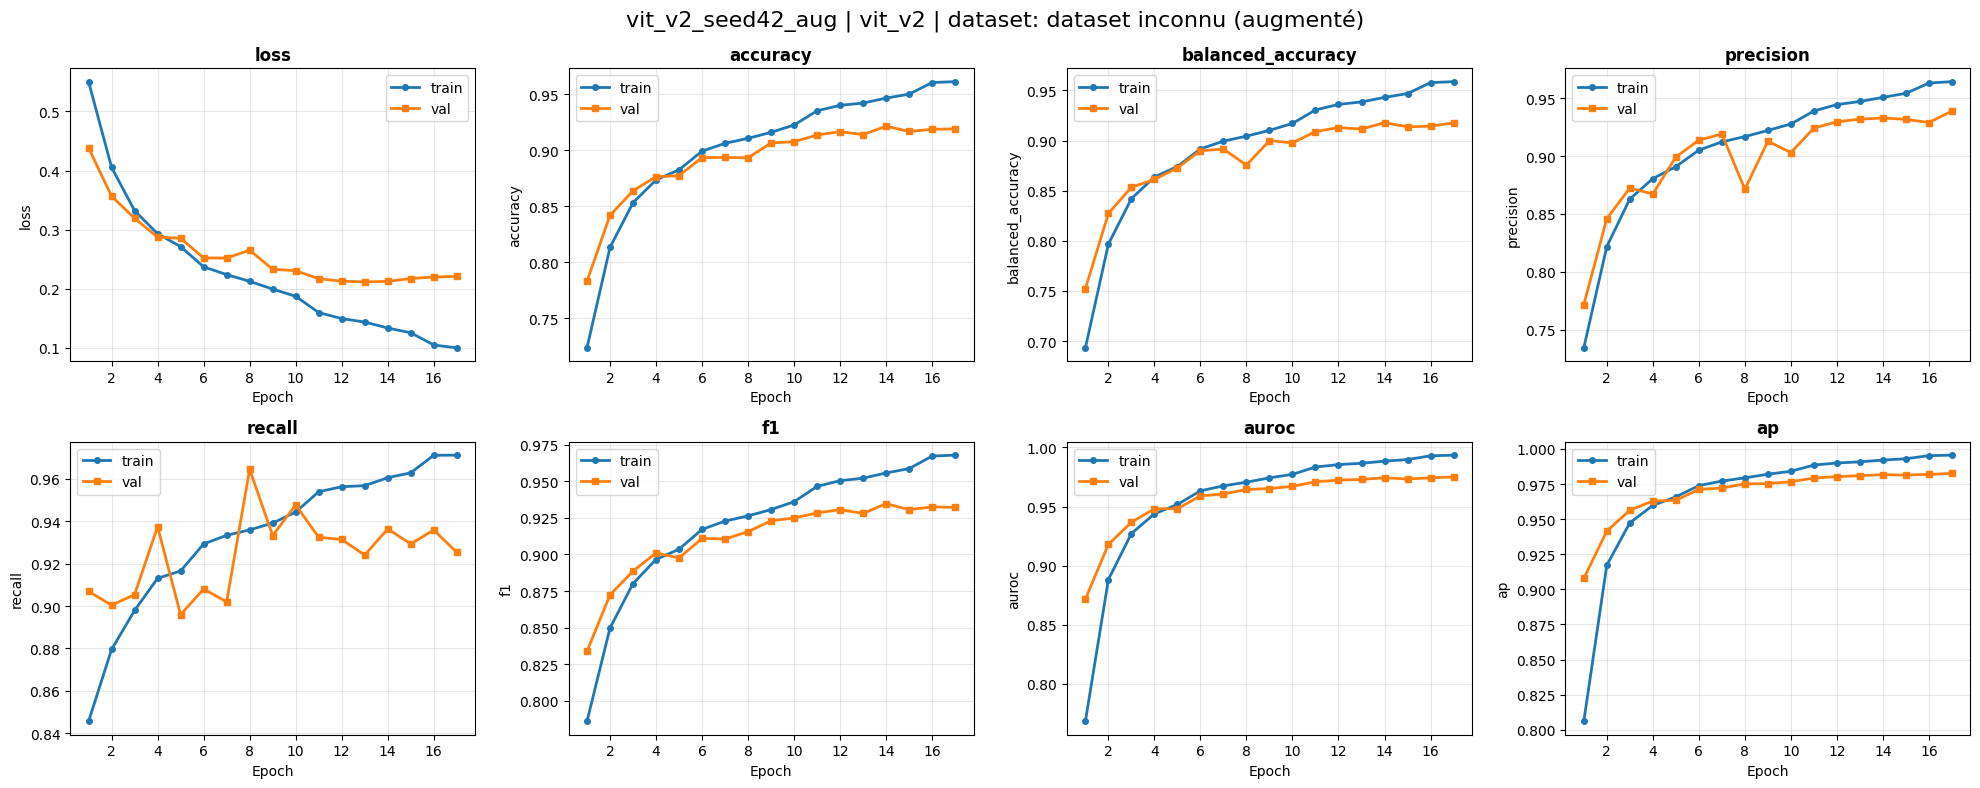

In [12]:
plot_all_runs2(records)

In [ ]:
#variante : comparer plusieurs runs sur une même métrique#
#utile pour comparer par exemple valf1 ou valloss entre tous les sous-dossiers.

In [18]:
def compare_runs(records, metric='f1', split='val',name_suffix=''):
    plt.figure(figsize=(12, 6))

    plotted = False
    for rec in records:
        history = rec['data'].get('history', [])
        if not history:
            continue

        df = history_to_dataframe(history)
        col = f'{split}_{metric}'
        if col not in df.columns:
            continue

        label = f"{rec['subdir']} ({rec['dataset_type']})"
        plt.plot(df['epoch'], df[col], label=label)
        plotted = True

    if not plotted:
        print(f'Aucune courbe disponible pour {split}_{metric}')
        return

    all_epochs = sorted({int(ep) for rec in records for ep in [item.get('epoch') for item in rec['data'].get('history', [])] if ep is not None})
    plt.title(f'Comparaison des runs | {split}_{metric}')
    plt.xlabel('Époque')
    plt.ylabel(f'{split}_{metric}')
    if all_epochs:
        plt.xticks(all_epochs)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'images/{name_suffix}_comparison_{split}_{metric}.png')
    plt.show()


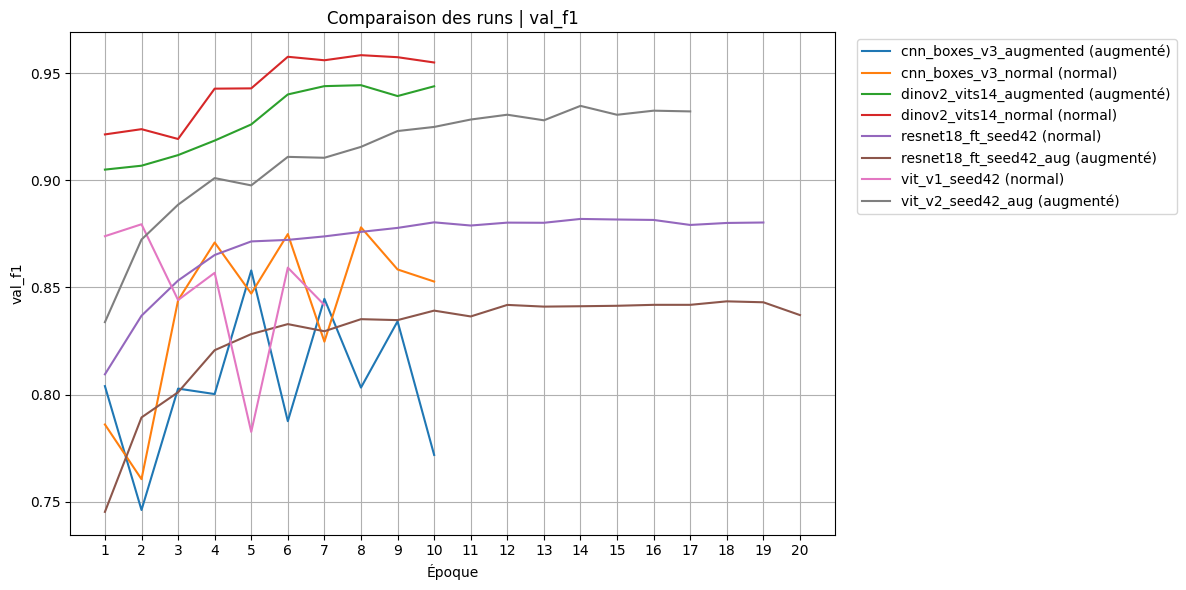

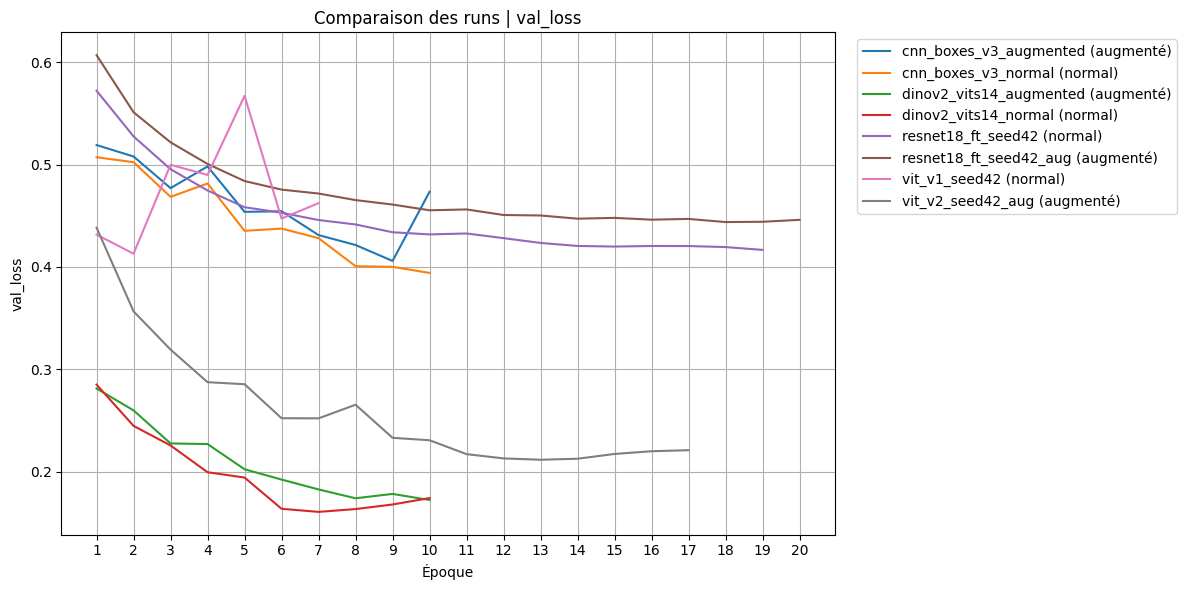

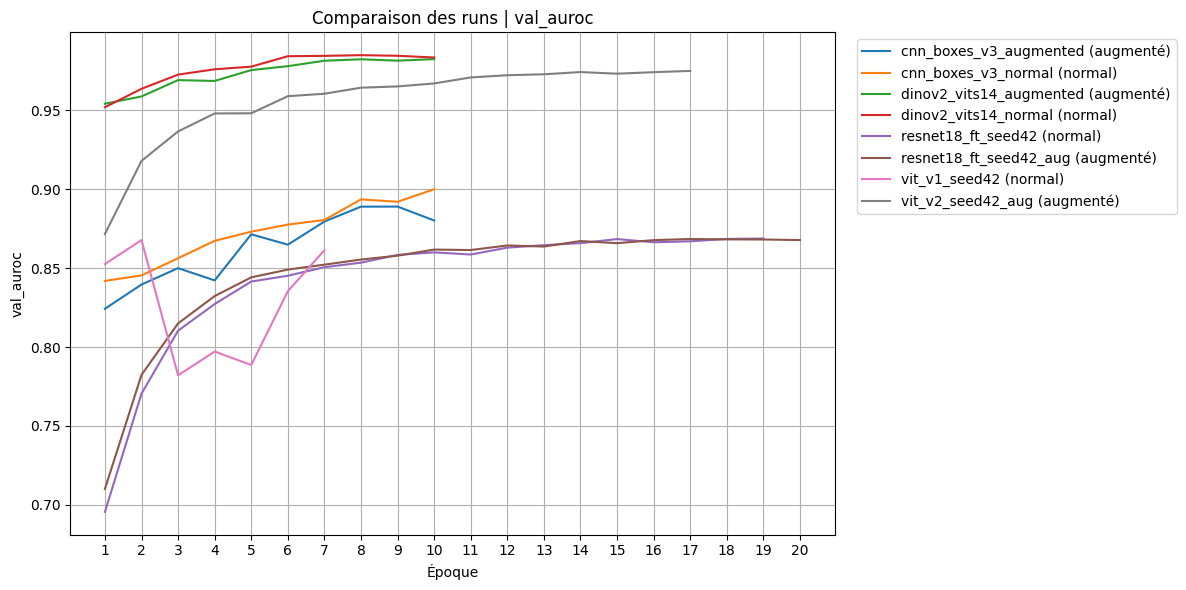

In [19]:
compare_runs(records, metric='f1', split='val')
compare_runs(records, metric='loss', split='val')
compare_runs(records, metric='auroc', split='val')

In [20]:
#séparer les runs normal / augmenté

In [21]:
normal_runs = [r for r in records if r['dataset_type'] == 'normal']
aug_runs = [r for r in records if r['dataset_type'] == 'augmenté']

print(f'Runs normales   : {len(normal_runs)}')
print(f'Runs augmentées : {len(aug_runs)}')

Runs normales   : 4
Runs augmentées : 4


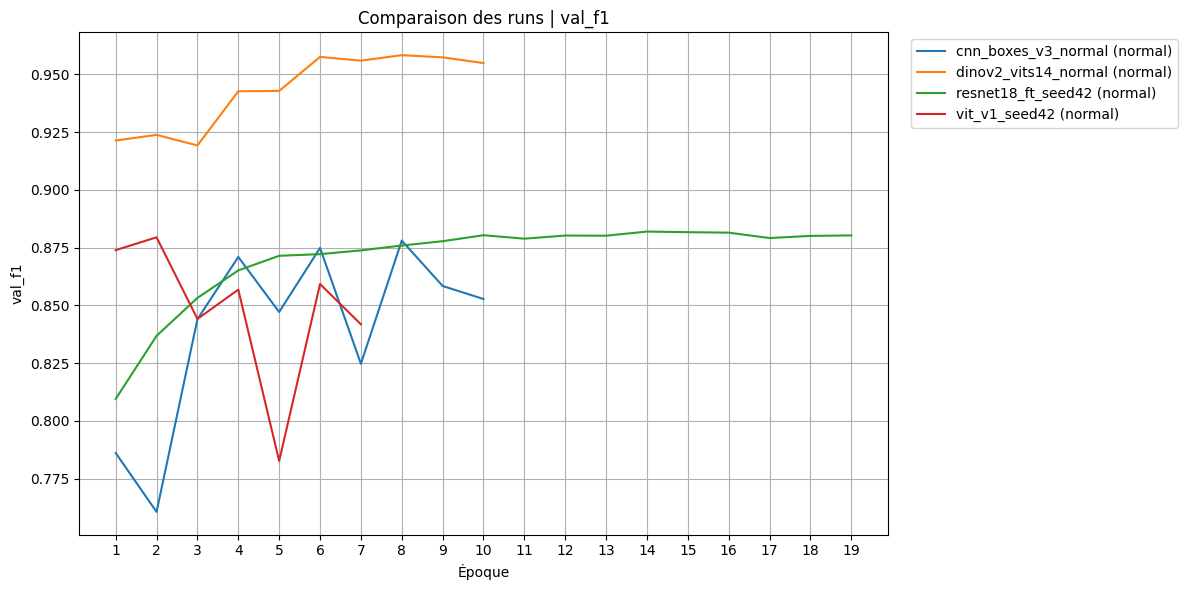

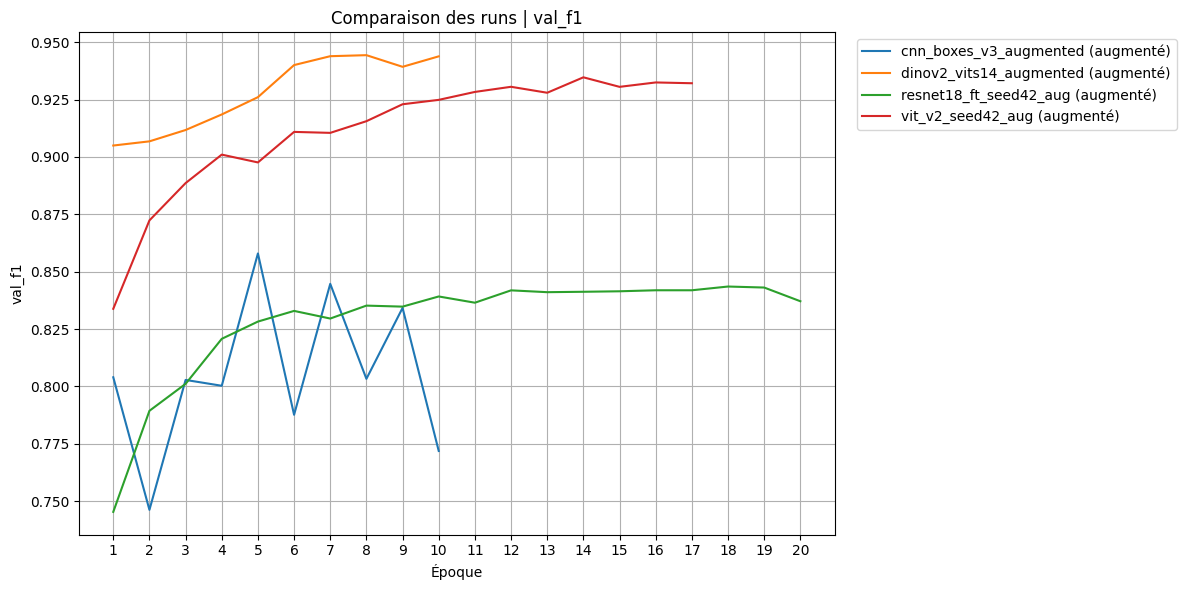

In [22]:
compare_runs(normal_runs, metric='f1', split='val',name_suffix='normal')
compare_runs(aug_runs, metric='f1', split='val',name_suffix='augmented')